Found 4 score files


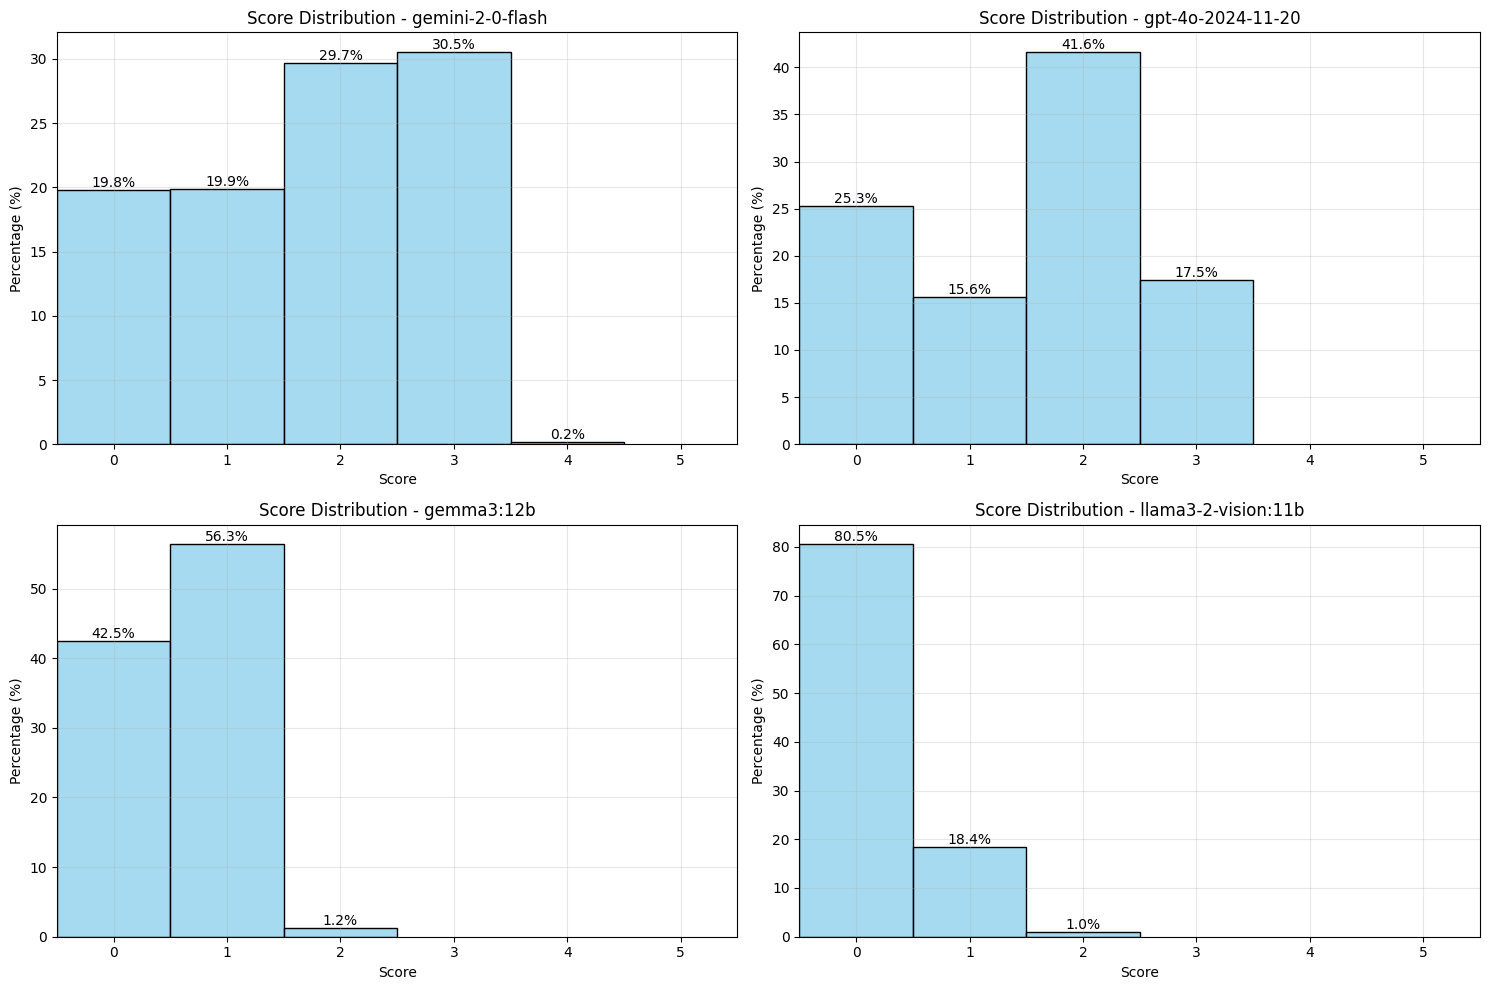

In [1]:
import math
import pandas as pd
import os
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List

def plot_score_distribution(scores: List[float], ax=None) -> None:
    """Creates a distribution plot for a list of scores as percentages.

    Args:
        scores: A list of numerical scores (0-5) to be plotted.
        ax: Optional matplotlib axis to plot on.
    """
    if ax is None:
        ax = plt.gca()

    # Plot histogram as percentages
    sns.histplot(
        data=scores,
        stat='percent',
        kde=False,
        bins=range(7),
        color="skyblue",
        discrete=True,
        ax=ax
    )
    ax.set_xlabel("Score")
    ax.set_ylabel("Percentage (%)")
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(6))
    ax.set_xlim(-0.5, 5.5)

    # Add percentage labels on top of bars
    for p in ax.patches:
        percentage = f'{p.get_height():.1f}%'
        ax.annotate(
            percentage,
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center',
            va='bottom'
        )

# Define base path
base_path = Path('/Users/tyrionhuu/projects/research_projects/PPTBench-Eval/data/generation_results/scores')

# Check if the base path exists
if not base_path.exists():
    print(f"Path does not exist: {base_path}")
    score_files = []
else:
    # Find all CSV files with "scores" in the name
    score_files = list(base_path.glob("*_scores.csv"))
    print(f"Found {len(score_files)} score files")

if not score_files:
    print("No score files found in the specified directory!")
else:
    # Calculate number of rows needed for 2 columns
    num_plots = len(score_files)
    num_rows = math.ceil(num_plots / 2)

    # Create subplot grid
    fig, axes = plt.subplots(num_rows, 2, figsize=(15, 5 * num_rows))
    axes = axes.flatten()

    valid_idx = 0  # Track index of non-skipped plots

    for file in score_files:
        model_name = file.stem.replace('_scores', '')

        # Check if file is empty
        if os.stat(file).st_size == 0:
            print(f"Skipping empty file: {file}")
            continue

        try:
            df = pd.read_csv(file)
        except pd.errors.EmptyDataError:
            print(f"Skipping empty or invalid file: {file}")
            continue

        if 'score' not in df.columns:
            print(f"File {file} has no 'score' column. Skipping.")
            continue

        scores = df['score'].tolist()
        ax = axes[valid_idx]
        plot_score_distribution(scores, ax=ax)
        ax.set_title(f"Score Distribution - {model_name}")
        valid_idx += 1

    # Remove any unused subplots
    for i in range(valid_idx, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()
